 # TASK 3: Chess Piece Detection and Board Digital Twin - YOLO

In [13]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from IPython.display import clear_output
import os
import torch
from torch.utils.data import Dataset
import pandas as pd
from pprint import pprint
import shutil
from pathlib import Path
import yaml
from ultralytics import YOLO
from yolo_script import detect_chess_pieces

 ## STEP 1: Data Analysis and Understanding

 **Topics:**

 - Explore JSON annotation structure

 - Understand piece categories and positions

 - Visualize sample images with bounding boxes

 - Create dataset for YOLO processing

In [2]:
def explore_json_structure(file_path, max_depth=3, max_items=5):
    """Explore and display the structure of a JSON file"""
    
    def explore_dict(obj, depth=0, prefix=""):
        if depth >= max_depth:
            print(f"{prefix}... (max depth reached)")
            return
            
        for key, value in obj.items():
            if isinstance(value, dict):
                print(f"{prefix}{key}: dict with {len(value)} keys")
                if len(value) <= 10:
                    explore_dict(value, depth + 1, prefix + "  ")
                else:
                    print(f"{prefix}  Keys: {list(value.keys())[:10]}{'...' if len(value) > 10 else ''}")
            elif isinstance(value, list):
                print(f"{prefix}{key}: list with {len(value)} items")
                if len(value) > 0:
                    print(f"{prefix}  First item type: {type(value[0])}")
                    if isinstance(value[0], dict):
                        print(f"{prefix}  Sample item keys: {list(value[0].keys())}")
                        if depth < max_depth - 1:
                            print(f"{prefix}  Sample item structure:")
                            explore_dict(value[0], depth + 1, prefix + "    ")
                    elif len(value) <= max_items:
                        print(f"{prefix}  Items: {value}")
            else:
                if isinstance(value, str) and len(value) > 50:
                    print(f"{prefix}{key}: {type(value).__name__} (length: {len(value)}) - '{value[:50]}...'")
                else:
                    print(f"{prefix}{key}: {type(value).__name__} = {value}")
    
    print(f"Loading JSON file: {file_path}")
    print("=" * 50)
    
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    print(f"Root type: {type(data)}")
    
    if isinstance(data, dict):
        print(f"Root keys: {list(data.keys())}")
        print("\nDetailed structure:")
        print("-" * 30)
        explore_dict(data)
    elif isinstance(data, list):
        print(f"Root list length: {len(data)}")
        if len(data) > 0:
            print(f"First item type: {type(data[0])}")
            if isinstance(data[0], dict):
                print(f"First item keys: {list(data[0].keys())}")
    
    return data

def quick_stats(data):
    """Show quick statistics about the loaded data"""
    print("\n" + "=" * 50)
    print("QUICK STATISTICS")
    print("=" * 50)
    
    if isinstance(data, dict):
        for key, value in data.items():
            if isinstance(value, list):
                print(f"{key}: {len(value)} items")
                if len(value) > 0 and isinstance(value[0], dict):
                    sample_keys = list(value[0].keys())
                    print(f"  Sample item keys: {sample_keys}")
            elif isinstance(value, dict):
                print(f"{key}: dict with {len(value)} keys")
            else:
                print(f"{key}: {type(value).__name__}")

# Load and explore annotations
annotations = explore_json_structure('annotations.json')
quick_stats(annotations)

Loading JSON file: annotations.json
Root type: <class 'dict'>
Root keys: ['info', 'images', 'annotations', 'categories', 'splits']

Detailed structure:
------------------------------
info: dict with 5 keys
  description: str = Chess Recognition Dataset (ChessReD)
  version: str = 1.0
  year: int = 2023
  date_created: str = 26/08/2023
  author: str = Athanasios Masouris
images: list with 10800 items
  First item type: <class 'dict'>
  Sample item keys: ['file_name', 'path', 'camera', 'height', 'width', 'game_id', 'move_id', 'id']
  Sample item structure:
    file_name: str = G000_IMG000.jpg
    path: str = images/0/G000_IMG000.jpg
    camera: str = Huawei P40 pro
    height: int = 3072
    width: int = 3072
    game_id: int = 0
    move_id: int = 0
    id: int = 0
annotations: dict with 2 keys
  pieces: list with 223804 items
    First item type: <class 'dict'>
    Sample item keys: ['image_id', 'category_id', 'chessboard_position', 'id', 'bbox']
    Sample item structure:
      image_

In [3]:
def chesspos2number(chesspos):
    col = ord(chesspos[0])-ord('a')
    row = int(chesspos[1])-1
    return row, col

class ChessDatasetForYOLO(Dataset):
    def __init__(self, root_dir, partition, transform=None):
        self.anns = json.load(open(os.path.join(root_dir, 'annotations.json')))
        self.categories = {c['id']: c['name'] for c in self.anns['categories']}
        self.root = root_dir
        self.ids = []
        self.file_names = []
        
        for x in self.anns['images']:
            self.file_names.append(x['path'])
            self.ids.append(x['id'])
        
        self.file_names = np.asarray(self.file_names)
        self.ids = np.asarray(self.ids)

        # Get ChessReD2K subset
        if partition == 'train':
            self.split_ids = np.asarray(self.anns['splits']['chessred2k']['train']['image_ids']).astype(int)
        elif partition == 'valid':
            self.split_ids = np.asarray(self.anns['splits']['chessred2k']['val']['image_ids']).astype(int)
        else:
            self.split_ids = np.asarray(self.anns['splits']['chessred2k']['test']['image_ids']).astype(int)

        intersect = np.isin(self.ids, self.split_ids)
        self.split_indices = np.where(intersect)[0]
        self.file_names = self.file_names[self.split_indices]
        self.ids = self.ids[self.split_indices]
        
        # Group piece annotations by image_id
        self.annotations_by_image = {}
        for ann in self.anns['annotations']['pieces']:
            image_id = ann['image_id']
            if image_id in self.split_ids:
                if image_id not in self.annotations_by_image:
                    self.annotations_by_image[image_id] = []
                self.annotations_by_image[image_id].append(ann)

        self.transform = transform
        print(f"Number of {partition} images: {len(self.file_names)}")
        print(f"Images with annotations: {len(self.annotations_by_image)}")

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, i):
        image_path = os.path.join(self.root, self.file_names[i])
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        image_id = self.ids[i]
        annotations = self.annotations_by_image.get(image_id, [])
        
        return image, annotations, image_id, self.file_names[i]

# Create dataset for visualization
dataset = ChessDatasetForYOLO('', 'train')
print(f"Total images with bounding boxes: {len(dataset)}")

Number of train images: 1442
Images with annotations: 1442
Total images with bounding boxes: 1442


Image 10/10
Image ID: 8016
Path: images/72/G072_IMG050.jpg
Original image size: (3072, 3072, 3)
Number of pieces: 16


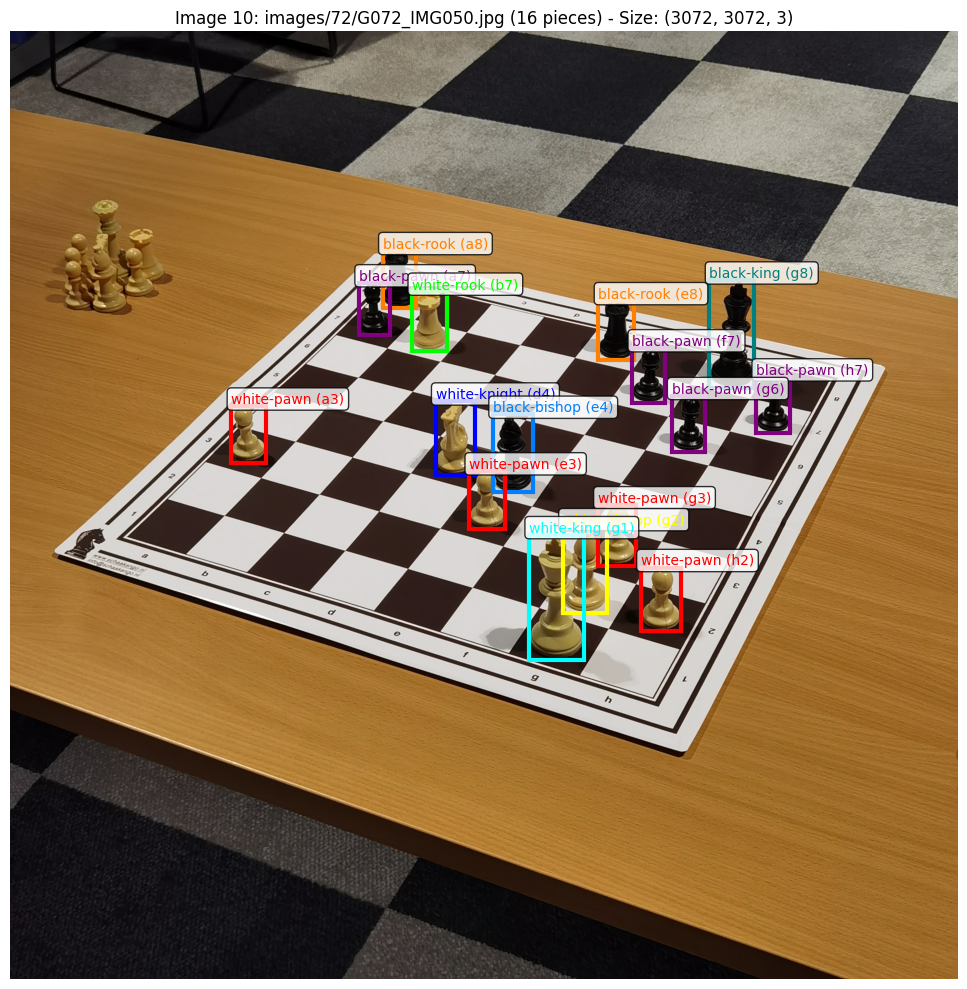

Pieces detected:
  black-bishop: 1 at positions [e4]
  black-king: 1 at positions [g8]
  black-pawn: 4 at positions [a7, f7, h7, g6]
  black-rook: 2 at positions [a8, e8]
  white-bishop: 1 at positions [g2]
  white-king: 1 at positions [g1]
  white-knight: 1 at positions [d4]
  white-pawn: 4 at positions [a3, e3, g3, h2]
  white-rook: 1 at positions [b7]

Sample annotation structure:
  image_id: 8016 (int)
  category_id: 7 (int)
  chessboard_position: a8 (str)
  id: 162877 (int)
  bbox: [1207.83, 710.42, 109.2, 185.77] (list)


In [4]:
# Interactive visualization with clear_output (10 random images)
random_indices = random.sample(range(len(dataset)), min(10, len(dataset)))

print(f"Selected {len(random_indices)} random images to display")
print("\nPiece categories:")
for cat_id, cat_name in dataset.categories.items():
    print(f"  {cat_id}: {cat_name}")
print("\nStarting visualization...")

# Define colors for different piece types
colors = {
    0: (255, 0, 0),    # white-pawn: Red
    1: (0, 255, 0),    # white-bishop: Green  
    2: (0, 0, 255),    # white-knight: Blue
    3: (255, 255, 0),  # white-rook: Yellow
    4: (255, 0, 255),  # white-queen: Magenta
    5: (0, 255, 255),  # white-king: Cyan
    6: (128, 0, 128),  # black-pawn: Purple
    7: (255, 128, 0),  # black-bishop: Orange
    8: (128, 128, 0),  # black-knight: Olive
    9: (0, 128, 255),  # black-rook: Light Blue
    10: (128, 0, 255), # black-queen: Violet
    11: (0, 128, 128), # black-king: Teal
    12: (192, 192, 192) # unknown: Gray
}

# Convert colors to 0-1 range for matplotlib
colors = {k: (v[0]/255, v[1]/255, v[2]/255) for k, v in colors.items()}

# Process each selected image with clear_output
for i, idx in enumerate(random_indices):
    clear_output(wait=True)
    
    # Get image and annotations from dataset
    image, annotations, image_id, img_path = dataset[idx]
    
    print(f"Image {i+1}/10")
    print(f"Image ID: {image_id}")
    print(f"Path: {img_path}")
    print(f"Original image size: {image.shape}")
    print(f"Number of pieces: {len(annotations)}")
    
    # Display image with bounding boxes
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    ax.imshow(image)
    
    # Draw bounding boxes
    for ann in annotations:
        bbox = ann['bbox']
        x, y, w, h = bbox
        
        category_id = ann['category_id']
        category_name = dataset.categories[category_id]
        chessboard_pos = ann.get('chessboard_position', 'unknown')
        
        color = colors.get(category_id, (0.5, 0.5, 0.5))
        
        from matplotlib.patches import Rectangle
        rect = Rectangle((x, y), w, h, linewidth=3, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        
        label = f"{category_name} ({chessboard_pos})"
        ax.text(x, y-10, label, fontsize=10, color=color, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
    
    ax.set_title(f"Image {i+1}: {img_path} ({len(annotations)} pieces) - Size: {image.shape}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Print piece details
    piece_counts = {}
    piece_positions = {}
    for ann in annotations:
        cat_name = dataset.categories[ann['category_id']]
        chessboard_pos = ann.get('chessboard_position', 'unknown')
        piece_counts[cat_name] = piece_counts.get(cat_name, 0) + 1
        if cat_name not in piece_positions:
            piece_positions[cat_name] = []
        piece_positions[cat_name].append(chessboard_pos)
    
    print("Pieces detected:")
    for piece, count in sorted(piece_counts.items()):
        positions = ', '.join(piece_positions[piece])
        print(f"  {piece}: {count} at positions [{positions}]")
    
    # Show sample annotation structure
    if annotations:
        print(f"\nSample annotation structure:")
        sample_ann = annotations[0]
        for key, value in sample_ann.items():
            print(f"  {key}: {value} ({type(value).__name__})")
    
    time.sleep(1)

 ## STEP 2: YOLO Dataset Creation

 **Topics:**

 - Convert COCO format to YOLO format

 - Create proper directory structure

 - Generate data.yaml configuration

 - Process train/val/test splits

In [5]:
def create_yolo_dataset(annotations_path='annotations.json', source_images_dir='', output_dir='yolo_ds'):
    """Convert ChessReD dataset to YOLO format"""
    
    print("Loading annotations...")
    with open(annotations_path, 'r') as f:
        anns = json.load(f)
    
    # Create output directory structure
    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True)
    
    for split in ['train', 'val', 'test']:
        images_dir = output_path / 'images' / split
        labels_dir = output_path / 'labels' / split
        images_dir.mkdir(parents=True, exist_ok=True)
        labels_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"Created directory structure in {output_dir}")
    
    # Create image ID to info mapping
    image_info = {img['id']: img for img in anns['images']}
    
    # Process each split
    splits = {
        'train': anns['splits']['chessred2k']['train']['image_ids'],
        'val': anns['splits']['chessred2k']['val']['image_ids'], 
        'test': anns['splits']['chessred2k']['test']['image_ids']
    }
    
    # Group annotations by image_id for ChessReD2K images only
    chessred2k_image_ids = set()
    for split_name, image_ids in splits.items():
        chessred2k_image_ids.update(image_ids)
    
    annotations_by_image = {}
    for ann in anns['annotations']['pieces']:
        image_id = ann['image_id']
        if image_id in chessred2k_image_ids:
            if image_id not in annotations_by_image:
                annotations_by_image[image_id] = []
            annotations_by_image[image_id].append(ann)
    
    print(f"Found annotations for {len(annotations_by_image)} ChessReD2K images")
    
    # Process each split
    for split_name, image_ids in splits.items():
        print(f"\nProcessing {split_name} split...")
        
        copied_images = 0
        created_labels = 0
        
        for image_id in image_ids:
            if image_id not in image_info:
                print(f"Warning: Image ID {image_id} not found in image info")
                continue
                
            img_info = image_info[image_id]
            source_path = os.path.join(source_images_dir, img_info['path'])
            
            if not os.path.exists(source_path):
                print(f"Warning: Source image not found: {source_path}")
                continue
            
            # Copy image
            image_filename = f"{img_info['file_name']}"
            dest_image_path = output_path / 'images' / split_name / image_filename
            shutil.copy2(source_path, dest_image_path)
            copied_images += 1
            
            # Create label file
            label_filename = f"{Path(img_info['file_name']).stem}.txt"
            label_path = output_path / 'labels' / split_name / label_filename
            
            image_annotations = annotations_by_image.get(image_id, [])
            
            # Convert annotations to YOLO format
            img_width = img_info['width']
            img_height = img_info['height']
            
            with open(label_path, 'w') as f:
                for ann in image_annotations:
                    x, y, w, h = ann['bbox']
                    
                    # Convert to YOLO format [x_center, y_center, width, height] normalized
                    x_center = (x + w/2) / img_width
                    y_center = (y + h/2) / img_height
                    norm_width = w / img_width
                    norm_height = h / img_height
                    
                    class_id = ann['category_id']
                    
                    f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {norm_width:.6f} {norm_height:.6f}\n")
            
            created_labels += 1
        
        print(f"  Copied {copied_images} images")
        print(f"  Created {created_labels} label files")
    
    # Create data.yaml file
    categories = anns['categories']
    class_names = [cat['name'] for cat in sorted(categories, key=lambda x: x['id'])]
    
    yaml_content = f"""train: ./images/train
val: ./images/val
test: ./images/test

nc: {len(class_names)}
names: {class_names}
"""
    
    with open(output_path / 'data.yaml', 'w') as f:
        f.write(yaml_content)
    
    print(f"\nCreated data.yaml with {len(class_names)} classes")
    print(f"Class names: {class_names}")
    
    print(f"\n{'='*50}")
    print("YOLO Dataset Creation Complete!")
    print(f"{'='*50}")
    print(f"Output directory: {output_dir}")
    print(f"Structure:")
    print(f"  images/")
    print(f"    train/ ({len(splits['train'])} images)")
    print(f"    val/ ({len(splits['val'])} images)")
    print(f"    test/ ({len(splits['test'])} images)")
    print(f"  labels/")
    print(f"    train/ ({len(splits['train'])} txt files)")
    print(f"    val/ ({len(splits['val'])} txt files)")
    print(f"    test/ ({len(splits['test'])} txt files)")
    print(f"  data.yaml")
    print(f"\nReady for YOLO training!")

create_yolo_dataset(
    annotations_path='annotations.json',
    source_images_dir='',
    output_dir='yolo_ds'
)

Loading annotations...
Created directory structure in yolo_ds
Found annotations for 2078 ChessReD2K images

Processing train split...
  Copied 1442 images
  Created 1442 label files

Processing val split...
  Copied 330 images
  Created 330 label files

Processing test split...
  Copied 306 images
  Created 306 label files

Created data.yaml with 13 classes
Class names: ['white-pawn', 'white-rook', 'white-knight', 'white-bishop', 'white-queen', 'white-king', 'black-pawn', 'black-rook', 'black-knight', 'black-bishop', 'black-queen', 'black-king', 'empty']

YOLO Dataset Creation Complete!
Output directory: yolo_ds
Structure:
  images/
    train/ (1442 images)
    val/ (330 images)
    test/ (306 images)
  labels/
    train/ (1442 txt files)
    val/ (330 txt files)
    test/ (306 txt files)
  data.yaml

Ready for YOLO training!


 ## STEP 3: Dataset Verification

 **Topics:**

 - Load and verify YOLO format annotations

 - Convert YOLO coordinates back to pixel coordinates

 - Visualize verification results

 - Check data integrity

Image 10/10
Split: train
Image: G041_IMG068.jpg
Label: G041_IMG068.txt
Image size: 3024x3024
Number of annotations: 14


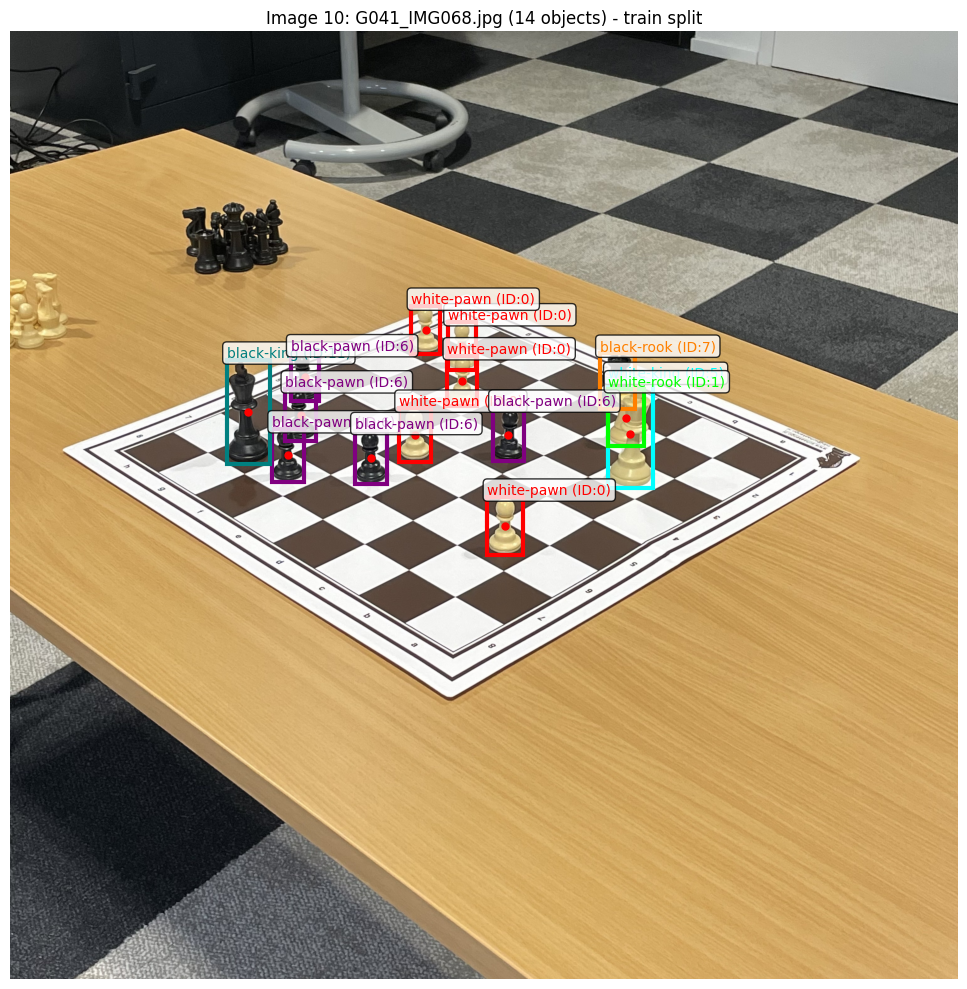


Annotation details:
  black-pawn: center=(0.293, 0.447), size=(0.034, 0.056)
  black-king: center=(0.251, 0.402), size=(0.045, 0.110)
  white-pawn: center=(0.522, 0.522), size=(0.037, 0.061)
  black-pawn: center=(0.381, 0.450), size=(0.034, 0.057)
  black-pawn: center=(0.307, 0.405), size=(0.033, 0.054)
  white-pawn: center=(0.427, 0.426), size=(0.034, 0.056)
  black-pawn: center=(0.311, 0.365), size=(0.030, 0.051)
  black-pawn: center=(0.526, 0.425), size=(0.033, 0.056)
  white-king: center=(0.654, 0.425), size=(0.047, 0.113)
  white-pawn: center=(0.477, 0.369), size=(0.031, 0.052)
  white-rook: center=(0.650, 0.408), size=(0.037, 0.061)
  white-pawn: center=(0.477, 0.332), size=(0.030, 0.051)
  white-pawn: center=(0.439, 0.315), size=(0.030, 0.050)
  black-rook: center=(0.641, 0.369), size=(0.037, 0.059)

Class distribution:
  black-king: 1
  black-pawn: 5
  black-rook: 1
  white-king: 1
  white-pawn: 5
  white-rook: 1


In [6]:
def load_yolo_annotations(label_path):
    """Load YOLO format annotations from a text file"""
    annotations = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                line = line.strip()
                if line:
                    parts = line.split()
                    class_id = int(parts[0])
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])
                    annotations.append({
                        'class_id': class_id,
                        'x_center': x_center,
                        'y_center': y_center,
                        'width': width,
                        'height': height
                    })
    return annotations

def yolo_to_bbox(x_center, y_center, width, height, img_width, img_height):
    """Convert YOLO format to bounding box coordinates"""
    x_center_px = x_center * img_width
    y_center_px = y_center * img_height
    width_px = width * img_width
    height_px = height * img_height
    
    x = x_center_px - width_px / 2
    y = y_center_px - height_px / 2
    
    return x, y, width_px, height_px

def verify_yolo_dataset(dataset_dir='yolo_ds', num_samples=10):
    """Verify YOLO dataset by visualizing random samples"""
    
    dataset_path = Path(dataset_dir)
    
    # Load class names from data.yaml
    yaml_path = dataset_path / 'data.yaml'
    if yaml_path.exists():
        with open(yaml_path, 'r') as f:
            data_config = yaml.safe_load(f)
        class_names = data_config['names']
        print(f"Loaded {len(class_names)} classes: {class_names}")
    else:
        print("Warning: data.yaml not found, using generic class names")
        class_names = [f"class_{i}" for i in range(13)]
    
    # Define colors for each class
    colors = [
        (255, 0, 0),    # red
        (0, 255, 0),    # green
        (0, 0, 255),    # blue
        (255, 255, 0),  # yellow
        (255, 0, 255),  # magenta
        (0, 255, 255),  # cyan
        (128, 0, 128),  # purple
        (255, 128, 0),  # orange
        (128, 128, 0),  # olive
        (0, 128, 255),  # light blue
        (128, 0, 255),  # violet
        (0, 128, 128),  # teal
        (192, 192, 192) # gray
    ]
    
    # Convert to 0-1 range for matplotlib
    colors = [(r/255, g/255, b/255) for r, g, b in colors]
    
    # Check available splits
    available_splits = []
    for split in ['train', 'val', 'test']:
        images_dir = dataset_path / 'images' / split
        if images_dir.exists() and any(images_dir.iterdir()):
            available_splits.append(split)
    
    if not available_splits:
        print("Error: No image directories found!")
        return
    
    print(f"Available splits: {available_splits}")
    
    # Collect all images from all splits
    all_images = []
    for split in available_splits:
        images_dir = dataset_path / 'images' / split
        labels_dir = dataset_path / 'labels' / split
        
        for img_path in images_dir.glob('*'):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                label_path = labels_dir / f"{img_path.stem}.txt"
                all_images.append({
                    'image_path': img_path,
                    'label_path': label_path,
                    'split': split
                })
    
    print(f"Found {len(all_images)} total images")
    
    # Select random samples
    if len(all_images) < num_samples:
        print(f"Warning: Only {len(all_images)} images available, showing all")
        selected_images = all_images
    else:
        selected_images = random.sample(all_images, num_samples)
    
    print(f"Displaying {len(selected_images)} random images...")
    print("\nStarting visualization...")
    
    # Process each selected image with clear_output
    for i, img_info in enumerate(selected_images):
        clear_output(wait=True)
        
        img_path = img_info['image_path']
        label_path = img_info['label_path']
        split = img_info['split']
        
        print(f"Image {i+1}/{len(selected_images)}")
        print(f"Split: {split}")
        print(f"Image: {img_path.name}")
        print(f"Label: {label_path.name}")
        
        # Load image
        image = cv2.imread(str(img_path))
        if image is None:
            print(f"Error: Could not load image {img_path}")
            continue
            
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_height, img_width = image_rgb.shape[:2]
        print(f"Image size: {img_width}x{img_height}")
        
        # Load annotations
        annotations = load_yolo_annotations(label_path)
        print(f"Number of annotations: {len(annotations)}")
        
        # Display image with bounding boxes
        fig, ax = plt.subplots(1, 1, figsize=(15, 10))
        ax.imshow(image_rgb)
        
        # Draw bounding boxes
        for ann in annotations:
            class_id = ann['class_id']
            
            # Convert YOLO format to bbox
            x, y, w, h = yolo_to_bbox(
                ann['x_center'], ann['y_center'], 
                ann['width'], ann['height'],
                img_width, img_height
            )
            
            class_name = class_names[class_id] if class_id < len(class_names) else f"class_{class_id}"
            color = colors[class_id % len(colors)]
            
            from matplotlib.patches import Rectangle
            rect = Rectangle((x, y), w, h, linewidth=3, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            
            label = f"{class_name} (ID:{class_id})"
            ax.text(x, y-10, label, fontsize=10, color=color, 
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
            
            # Add center point
            center_x = ann['x_center'] * img_width
            center_y = ann['y_center'] * img_height
            ax.plot(center_x, center_y, 'ro', markersize=5)
        
        ax.set_title(f"Image {i+1}: {img_path.name} ({len(annotations)} objects) - {split} split")
        ax.axis('off')
        plt.tight_layout()
        plt.show()
        
        # Print annotation details
        if annotations:
            print("\nAnnotation details:")
            class_counts = {}
            for ann in annotations:
                class_id = ann['class_id']
                class_name = class_names[class_id] if class_id < len(class_names) else f"class_{class_id}"
                class_counts[class_name] = class_counts.get(class_name, 0) + 1
                
                print(f"  {class_name}: center=({ann['x_center']:.3f}, {ann['y_center']:.3f}), "
                      f"size=({ann['width']:.3f}, {ann['height']:.3f})")
            
            print(f"\nClass distribution:")
            for class_name, count in sorted(class_counts.items()):
                print(f"  {class_name}: {count}")
        else:
            print("No annotations found for this image")
        
        time.sleep(1)

verify_yolo_dataset('yolo_ds', num_samples=10)

 ## STEP 4: YOLO Model Training

 **Topics:**

 - Configure YOLO training parameters

 - Train model on chess dataset

 - Save trained model

In [7]:
def train_yolo_model(data_yaml='yolo_ds/data.yaml', epochs=50, device='0'):
    """Train YOLO model on chess dataset"""
    print("Starting YOLO training...")
    
    model = YOLO('yolov8n.pt')
    
    results = model.train(
        data=data_yaml,
        epochs=epochs,
        imgsz=640,
        device=device,
        batch=16,
        name='chess_detection',
        patience=15,
        save=True,
        plots=True
    )
    
    model.save('yolo_chess_model.pt')
    print("Training complete! Model saved as 'yolo_chess_model.pt'")
    
    return model

# Uncomment to train
# train_yolo_model()

 ## STEP 5: Model Testing and Board Digital Twin

 **Topics:**

 - Load trained YOLO model

 - Test detection on chess images

 - Create board digital twin

 - Interactive visualization with clear_output

In [8]:
MODEL_PATH = 'yolo_chess_model.pt'
TEST_DATASET_PATH = 'yolo_ds'
DEVICE = '0'

# Color map for chess pieces
COLOR_MAP = {
    'white-pawn': (255, 0, 0),
    'white-bishop': (0, 255, 0),
    'white-knight': (0, 0, 255),
    'white-rook': (255, 255, 0),
    'white-queen': (255, 0, 255),
    'white-king': (0, 255, 255),
    'black-pawn': (128, 0, 128),
    'black-bishop': (255, 128, 0),
    'black-knight': (128, 128, 0),
    'black-rook': (0, 128, 255),
    'black-queen': (128, 0, 255),
    'black-king': (0, 128, 128)
}

def load_model(model_path, device='0'):
    """Load YOLO model"""
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found: {model_path}")
    
    device_str = 'cuda' if device != 'cpu' and torch.cuda.is_available() else 'cpu'
    model = YOLO(model_path)
    print(f"Model loaded on device: {device_str}")
    return model

def get_test_images(dataset_path, num_images=10):
    """Get random test images"""
    test_images_dir = Path(dataset_path) / 'images' / 'test'
    
    if not test_images_dir.exists():
        raise FileNotFoundError(f"Test images directory not found: {test_images_dir}")
    
    image_files = []
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        image_files.extend(list(test_images_dir.glob(ext)))
    
    if len(image_files) == 0:
        raise FileNotFoundError("No test images found")
    
    selected_images = random.sample(image_files, min(num_images, len(image_files)))
    print(f"Selected {len(selected_images)} random test images")
    
    return selected_images

def yolo_detect(model, image_path, device='0'):
    """Run YOLO detection on image"""
    device_str = 'cuda' if device != 'cpu' and torch.cuda.is_available() else 'cpu'
    
    results = model(
        image_path,
        show=False,
        save=False,
        imgsz=640,
        device=device_str,
        conf=0.25,
        iou=0.45
    )
    
    return results[0]

def draw_detections(image, result, class_names):
    """Draw bounding boxes and labels on image"""
    img_with_boxes = image.copy()
    
    if result.boxes is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        confidences = result.boxes.conf.cpu().numpy()
        class_ids = result.boxes.cls.cpu().numpy().astype(int)
        
        for i, (box, conf, class_id) in enumerate(zip(boxes, confidences, class_ids)):
            x1, y1, x2, y2 = box.astype(int)
            
            class_name = class_names[class_id] if class_id < len(class_names) else f'class_{class_id}'
            color = COLOR_MAP.get(class_name, (255, 255, 255))
            
            # Convert color to BGR for OpenCV
            color_bgr = (int(color[2]), int(color[1]), int(color[0]))
            
            # Draw bounding box
            cv2.rectangle(img_with_boxes, (x1, y1), (x2, y2), color_bgr, 2)
            
            # Draw label background
            label = f'{class_name} {conf:.2f}'
            label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)[0]
            cv2.rectangle(img_with_boxes, (x1, y1 - label_size[1] - 10), 
                         (x1 + label_size[0], y1), color_bgr, -1)
            
            # Draw label text
            cv2.putText(img_with_boxes, label, (x1, y1 - 5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    return img_with_boxes

Image 10/10
Processing: G000_IMG064.jpg
Image size: 3072x3072

image 1/1 c:\Users\danie\Desktop\UNI-4ano\VC\PROJECT2\yolo_ds\images\test\G000_IMG064.jpg: 640x640 3 white-pawns, 2 white-rooks, 1 white-knight, 1 white-king, 4 black-pawns, 2 black-rooks, 2 black-knights, 1 black-king, 29.0ms
Speed: 5.6ms preprocess, 29.0ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Detections: 16


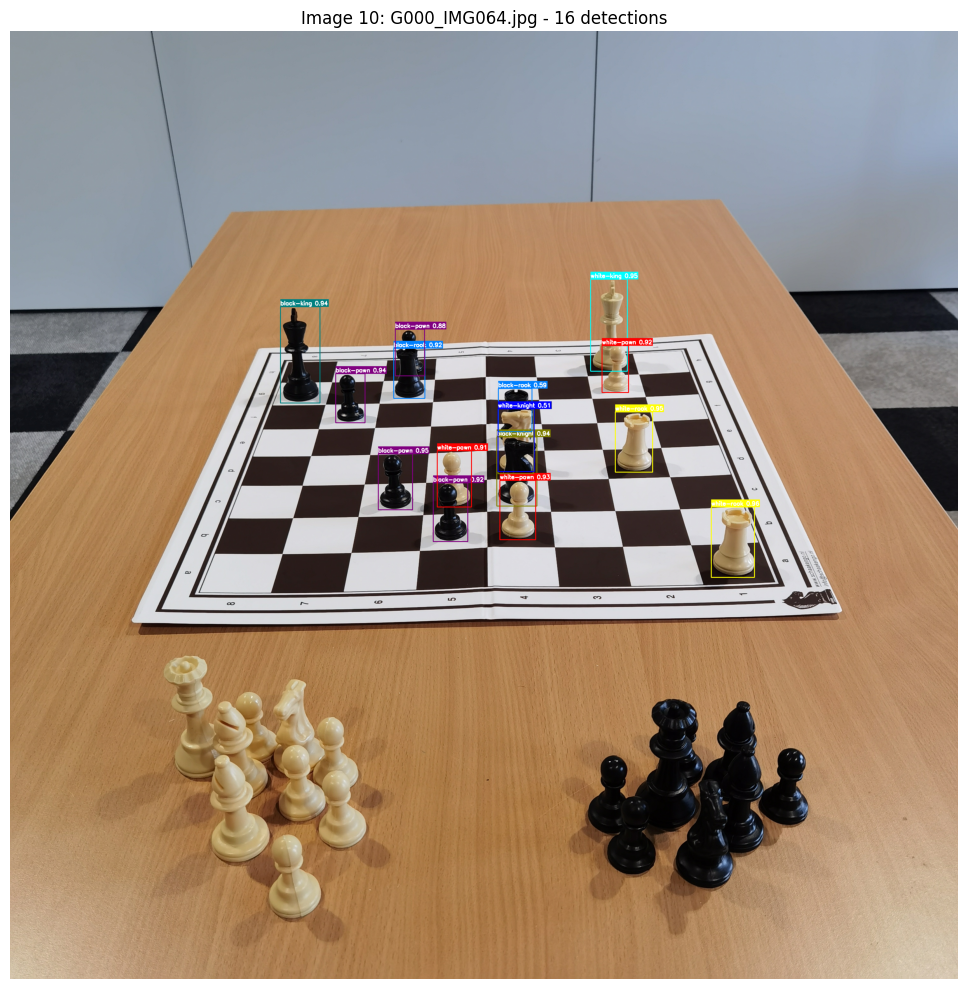

Detected pieces:
  white-rook: 0.958
  white-rook: 0.954
  white-king: 0.948
  black-pawn: 0.946
  black-king: 0.944
  black-pawn: 0.938
  black-knight: 0.937
  white-pawn: 0.933
  black-rook: 0.924
  black-pawn: 0.920
  white-pawn: 0.918
  white-pawn: 0.912
  black-pawn: 0.884
  black-knight: 0.641
  black-rook: 0.590
  white-knight: 0.505
Piece distribution:
  black-king: 1
  black-knight: 2
  black-pawn: 4
  black-rook: 2
  white-king: 1
  white-knight: 1
  white-pawn: 3
  white-rook: 2


In [9]:
# Interactive model testing
try:
    # Load model
    model = load_model(MODEL_PATH, DEVICE)
    class_names = model.names
    print(f"Model classes: {list(class_names.values())}")

    # Get test images
    test_images = get_test_images(TEST_DATASET_PATH, 10)

    print(f"\nStarting visualization of {len(test_images)} images...")

    # Process each image with clear_output
    for i, image_path in enumerate(test_images):
        clear_output(wait=True)
        
        print(f"Image {i+1}/{len(test_images)}")
        print(f"Processing: {image_path.name}")
        
        # Load image
        image = cv2.imread(str(image_path))
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image_rgb.shape[:2]
        print(f"Image size: {w}x{h}")
        
        # Run detection
        result = yolo_detect(model, str(image_path), DEVICE)
        
        # Count detections
        num_detections = len(result.boxes) if result.boxes is not None else 0
        print(f"Detections: {num_detections}")
        
        # Draw detections
        img_with_detections = draw_detections(image, result, class_names)
        img_with_detections_rgb = cv2.cvtColor(img_with_detections, cv2.COLOR_BGR2RGB)
        
        # Display
        plt.figure(figsize=(15, 10))
        plt.imshow(img_with_detections_rgb)
        plt.title(f"Image {i+1}: {image_path.name} - {num_detections} detections")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        # Print detection details
        if result.boxes is not None:
            print("Detected pieces:")
            boxes = result.boxes.xyxy.cpu().numpy()
            confidences = result.boxes.conf.cpu().numpy()
            class_ids = result.boxes.cls.cpu().numpy().astype(int)
            
            piece_counts = {}
            for conf, class_id in zip(confidences, class_ids):
                class_name = class_names[class_id]
                piece_counts[class_name] = piece_counts.get(class_name, 0) + 1
                print(f"  {class_name}: {conf:.3f}")
            
            print("Piece distribution:")
            for piece, count in sorted(piece_counts.items()):
                print(f"  {piece}: {count}")
        else:
            print("No pieces detected")
        
        time.sleep(1)

except FileNotFoundError as e:
    print(f"Model not found: {e}")
    print("Please train the model first or provide correct model path")

In [10]:
# Board Digital Twin Implementation
class ChessDigitalTwin:
    """Create digital twin of chess board state"""
    
    def __init__(self):
        self.board_state = {}
    
    def map_detections_to_board(self, detections, image_shape):
        """Map detected pieces to chess board positions"""
        h, w = image_shape[:2]
        board_state = {}
        
        for det in detections:
            if 'bbox' in det:
                x1, y1, x2, y2 = det['bbox']
                center_x = (x1 + x2) / 2
                center_y = (y1 + y2) / 2
                
                # Simple grid mapping (8x8 board)
                col = int((center_x / w) * 8)
                row = int((center_y / h) * 8)
                
                # Convert to chess notation
                chess_col = chr(ord('a') + min(col, 7))
                chess_row = str(8 - min(row, 7))
                chess_pos = chess_col + chess_row
                
                board_state[chess_pos] = {
                    'piece': det.get('class_name', det.get('class', 'unknown')),
                    'confidence': det.get('confidence', 0.0),
                    'bbox': det['bbox']
                }
        
        return board_state
    
    def print_board_state(self, board_state):
        """Print ASCII representation of board state"""
        print("\nBoard Digital Twin:")
        print("  a b c d e f g h")
        
        for row in range(8, 0, -1):
            line = f"{row} "
            for col in 'abcdefgh':
                pos = col + str(row)
                if pos in board_state:
                    piece = board_state[pos]['piece']
                    # Use piece symbols
                    if 'white' in piece:
                        symbol = piece.split('-')[1][0].upper()
                    else:
                        symbol = piece.split('-')[1][0].lower()
                    line += f"{symbol} "
                else:
                    line += ". "
            print(line)
    
    def analyze_board(self, board_state):
        """Analyze board state and provide statistics"""
        white_pieces = 0
        black_pieces = 0
        piece_types = {}
        
        for pos, info in board_state.items():
            piece = info['piece']
            if 'white' in piece:
                white_pieces += 1
            elif 'black' in piece:
                black_pieces += 1
            
            piece_types[piece] = piece_types.get(piece, 0) + 1
        
        print(f"\nBoard Analysis:")
        print(f"  White pieces: {white_pieces}")
        print(f"  Black pieces: {black_pieces}")
        print(f"  Total pieces: {len(board_state)}")
        print(f"  Piece distribution:")
        for piece, count in sorted(piece_types.items()):
            print(f"    {piece}: {count}")

# Create digital twin instance
digital_twin = ChessDigitalTwin()

Image 10/10
Processing: G000_IMG009.jpg

image 1/1 c:\Users\danie\Desktop\UNI-4ano\VC\PROJECT2\yolo_ds\images\test\G000_IMG009.jpg: 640x640 8 white-pawns, 2 white-rooks, 2 white-knights, 2 white-bishops, 1 white-queen, 1 white-king, 8 black-pawns, 2 black-rooks, 2 black-knights, 2 black-bishops, 1 black-queen, 1 black-king, 25.4ms
Speed: 4.6ms preprocess, 25.4ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)
Image size: 3072x3072
Detections: 32


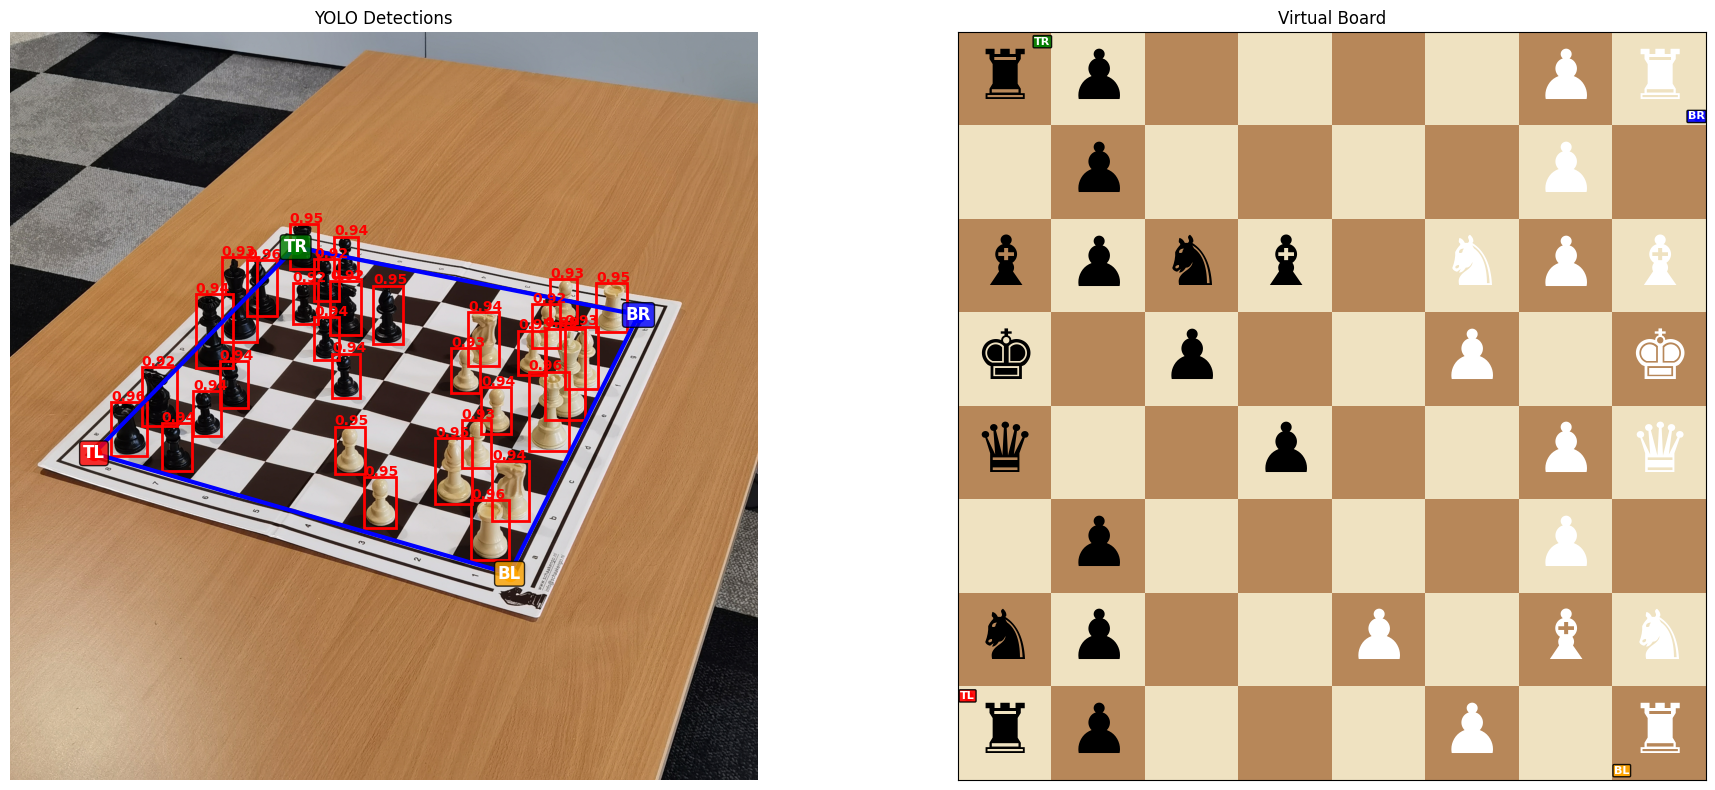

Detected pieces:
  a1: black-rook (0.963)
  h4: white-queen (0.962)
  a6: black-bishop (0.959)
  h1: white-rook (0.958)
  h8: white-rook (0.955)
  g2: white-bishop (0.952)
  g6: white-pawn (0.952)
  e2: white-pawn (0.951)
  a8: black-rook (0.951)
  d6: black-bishop (0.950)
  f1: white-pawn (0.945)
  h2: white-knight (0.945)
  b1: black-pawn (0.943)
  b2: black-pawn (0.940)
  d4: black-pawn (0.940)
  b8: black-pawn (0.939)
  a4: black-queen (0.939)
  c5: black-pawn (0.938)
  g4: white-pawn (0.937)
  b3: black-pawn (0.937)
  f6: white-knight (0.936)
  f5: white-pawn (0.935)
  h6: white-bishop (0.934)
  g3: white-pawn (0.933)
  g8: white-pawn (0.932)
  a5: black-king (0.928)
  b7: black-pawn (0.924)
  a2: black-knight (0.922)
  b6: black-pawn (0.920)
  c6: black-knight (0.920)
  g7: white-pawn (0.915)
  h5: white-king (0.887)
Piece distribution:
  black-bishop: 2
  black-king: 1
  black-knight: 2
  black-pawn: 8
  black-queen: 1
  black-rook: 2
  white-bishop: 2
  white-king: 1
  white-kn

In [14]:
def test_with_custom_script():
    """Test using custom chess detection script"""
    
    # Configuration
    MODEL_PATH = 'yolo_chess_model.pt'
    ANNOTATIONS_PATH = 'annotations.json'
    TEST_DATASET_PATH = 'yolo_ds'
    
    print("Chess Detection with Custom Script")
    print("=" * 40)
    
    # Get test images
    def get_test_images_list(dataset_path, num_images=10):
        test_path = Path(dataset_path) / "images" / "test"
        image_files = list(test_path.glob("*.jpg")) + list(test_path.glob("*.png"))
        return image_files[:num_images]
    
    test_images = get_test_images_list(TEST_DATASET_PATH, 10)
    print(f"Found {len(test_images)} test images")
    
    if not test_images:
        print("No test images found! Check your dataset path.")
        return
    
    print(f"\nStarting visualization of {len(test_images)} images...")
    
    # Process each image with clear_output
    for i, image_path in enumerate(test_images):
        clear_output(wait=True)
        
        print(f"Image {i+1}/{len(test_images)}")
        print(f"Processing: {image_path.name}")
        
        try:
            # Run chess detection
            fig, result = detect_chess_pieces(
                str(image_path), 
                MODEL_PATH, 
                ANNOTATIONS_PATH
            )
            
            # Display results
            print(f"Image size: {result['image'].shape[1]}x{result['image'].shape[0]}")
            print(f"Detections: {len(result['detections'])}")
            
            # Show visualization
            plt.show()
            
            # Print detection details
            if result['piece_info']:
                print("Detected pieces:")
                piece_counts = {}
                for square, info in result['piece_info'].items():
                    piece_name = info['name']
                    confidence = info['confidence']
                    piece_counts[piece_name] = piece_counts.get(piece_name, 0) + 1
                    print(f"  {square}: {piece_name} ({confidence:.3f})")
                
                print("Piece distribution:")
                for piece, count in sorted(piece_counts.items()):
                    print(f"  {piece}: {count}")
                    
                print(f"Total pieces on board: {len(result['piece_info'])}")
            else:
                print("No pieces detected on the board")
                
        except Exception as e:
            print(f"Error processing {image_path.name}: {e}")
            continue
        
        time.sleep(2)
    
    print("\nVisualization complete!")

# Run custom script test
test_with_custom_script()